# SAE timing benchmark

For the methods section's "computational requirements" question: how does SAE
train time and activation-compute time scale with the number of neurons `M`,
the number of respondents `N`, and the embedding dimensionality `D`?

**Method**: each benchmark point trains a *fresh* SAE (no checkpoint reuse) on
real survey-response embeddings, resampled (bootstrap) to reach the target `N`
and truncated to the target `D`, using random synthetic noise only when a
sweep value exceeds what the real data supports. No `val_embeddings` is passed,
so early stopping never triggers ([`SparseAutoencoder.fit`](../src) only checks
it when a validation set is given) — every run trains the full, fixed
`n_epochs`, so timings are a clean, deterministic function of `(N, D, M)`
rather than noisy convergence-dependent numbers.

Edit the `M_VALUES` / `N_VALUES` / `D_VALUES` lists in the sweep cells below to
test other sizes. Results are saved to `data/sae_timing_benchmark.csv`.

In [2]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
DATA_DIR = ROOT / "data"
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))

from hypothesaes.quickstart import train_sae
from train_sae import _device_summary  # reuse the same hardware-detection logic

DEVICE_INFO = _device_summary()
print(f"Hardware: {DEVICE_INFO['device']} ({DEVICE_INFO['device_name']}), "
      f"{DEVICE_INFO['cpu_count']} CPUs, {DEVICE_INFO['platform']}")

Hardware: mps (Apple Silicon (MPS)), 11 CPUs, macOS-15.7.7-arm64-arm-64bit


In [3]:
# Real embeddings as the statistical base for resampling/truncating.
# Using real data (not pure random noise) keeps SAE convergence behavior
# representative of the actual pipeline, even though early stopping is
# disabled here (see markdown above) so it doesn't affect wall-clock time.
BASE_EMBEDDINGS = np.load(DATA_DIR / "embeddings" / "race_embeddings.npy").astype(np.float32)
print(f"Base embeddings: {BASE_EMBEDDINGS.shape}")

rng = np.random.default_rng(0)

def resample_n(base, n):
    """Bootstrap-resample rows to reach n (with replacement if n > len(base))."""
    idx = rng.choice(len(base), size=n, replace=n > len(base))
    return base[idx]

def resize_dim(base, d):
    """Truncate to the first d dims, or tile+truncate if d exceeds the base dim."""
    if d <= base.shape[1]:
        return base[:, :d]
    reps = int(np.ceil(d / base.shape[1]))
    return np.tile(base, (1, reps))[:, :d]

Base embeddings: (1004, 3072)


In [5]:
def benchmark_sae(embeddings, M, K=4, n_epochs=100, show_progress=False):
    """Train a fresh SAE (no checkpoint) and time training + activation computation."""
    t0 = time.perf_counter()
    sae = train_sae(
        embeddings=embeddings, M=M, K=K,
        checkpoint_dir=None, n_epochs=n_epochs, show_progress=show_progress,
    )
    train_seconds = time.perf_counter() - t0

    X = torch.tensor(embeddings, dtype=torch.float32)
    t0 = time.perf_counter()
    _ = sae.get_activations(X, show_progress=show_progress)
    activations_seconds = time.perf_counter() - t0

    return {
        "n_responses": embeddings.shape[0],
        "embedding_dim": embeddings.shape[1],
        "M": M, "K": K, "n_epochs": n_epochs,
        "train_seconds": train_seconds,
        "activations_seconds": activations_seconds,
        "device": DEVICE_INFO["device"],
    }

## Sweep 1: vary `M` (number of SAE neurons)
Fixed `N=1004`, `D=3072` — matches the actual paper dataset.

In [16]:
M_VALUES = [16, 32, 64, 128, 256, 512, 1024, 2048]  # edit to test other sizes

results_M = []
for M in M_VALUES:
    print(f"Benchmarking M={M} ...")
    r = benchmark_sae(BASE_EMBEDDINGS, M=M)
    results_M.append(r)
    print(f"  train={r['train_seconds']:.1f}s  activations={r['activations_seconds']:.2f}s")

df_M = pd.DataFrame(results_M)
df_M

Benchmarking M=16 ...
  train=2.7s  activations=0.02s
Benchmarking M=32 ...
  train=2.6s  activations=0.00s
Benchmarking M=64 ...
  train=2.4s  activations=0.00s
Benchmarking M=128 ...
  train=2.8s  activations=0.00s
Benchmarking M=256 ...
  train=3.9s  activations=0.01s
Benchmarking M=512 ...
  train=5.7s  activations=0.01s
Benchmarking M=1024 ...
  train=10.9s  activations=0.02s
Benchmarking M=2048 ...
  train=19.3s  activations=0.03s


,n_responses,embedding_dim,M,K,n_epochs,train_seconds,activations_seconds,device
0,1004,3072,16,4,100,2.671590,0.016219,mps
1,1004,3072,32,4,100,2.607464,0.003967,mps
2,1004,3072,64,4,100,2.358474,0.003821,mps
3,1004,3072,128,4,100,2.769600,0.003939,mps
4,1004,3072,256,4,100,3.918514,0.005549,mps
5,1004,3072,512,4,100,5.724851,0.009154,mps
6,1004,3072,1024,4,100,10.921523,0.019534,mps
7,1004,3072,2048,4,100,19.330803,0.032185,mps


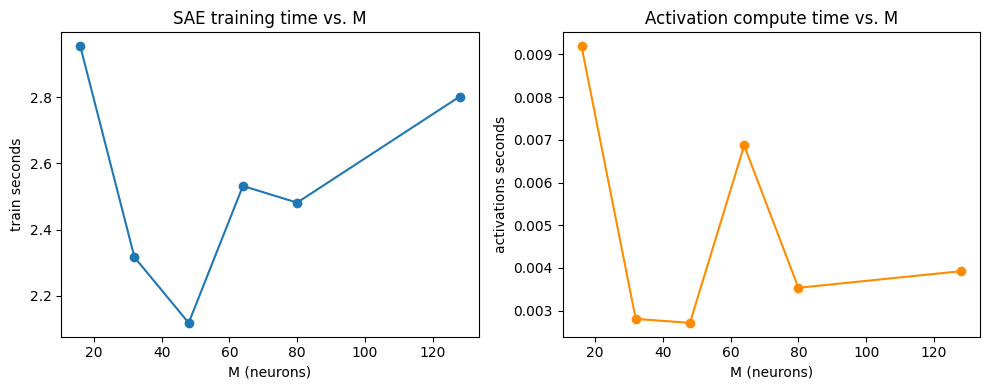

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(df_M["M"], df_M["train_seconds"], marker="o")
axes[0].set(xlabel="M (neurons)", ylabel="train seconds", title="SAE training time vs. M")
axes[1].plot(df_M["M"], df_M["activations_seconds"], marker="o", color="darkorange")
axes[1].set(xlabel="M (neurons)", ylabel="activations seconds", title="Activation compute time vs. M")
fig.tight_layout()
plt.show()

## Sweep 2: vary `N` (number of respondents)
Fixed `M=32`, `D=3072` — matches the paper default. `N` values above 1004 use
bootstrap resampling (with replacement) of the real embeddings.

In [13]:
N_VALUES = [100, 500, 1004, 2500, 5000, 20000, 50000]  # edit to test other sizes

results_N = []
for n in N_VALUES:
    emb_n = resample_n(BASE_EMBEDDINGS, n)
    print(f"Benchmarking N={n} ...")
    r = benchmark_sae(emb_n, M=32)
    results_N.append(r)
    print(f"  train={r['train_seconds']:.1f}s  activations={r['activations_seconds']:.2f}s")

df_N = pd.DataFrame(results_N)
df_N

Benchmarking N=100 ...
  train=0.4s  activations=0.00s
Benchmarking N=500 ...
  train=1.0s  activations=0.00s
Benchmarking N=1004 ...
  train=2.3s  activations=0.01s
Benchmarking N=2500 ...
  train=5.4s  activations=0.01s
Benchmarking N=5000 ...
  train=11.0s  activations=0.03s
Benchmarking N=20000 ...
  train=40.5s  activations=0.11s
Benchmarking N=50000 ...
  train=105.9s  activations=0.20s


,n_responses,embedding_dim,M,K,n_epochs,train_seconds,activations_seconds,device
0,100,3072,32,4,100,0.390225,0.000414,mps
1,500,3072,32,4,100,1.039452,0.001918,mps
2,1004,3072,32,4,100,2.338132,0.005157,mps
3,2500,3072,32,4,100,5.366632,0.010215,mps
4,5000,3072,32,4,100,11.002080,0.026104,mps
5,20000,3072,32,4,100,40.489325,0.111720,mps
6,50000,3072,32,4,100,105.874020,0.196597,mps


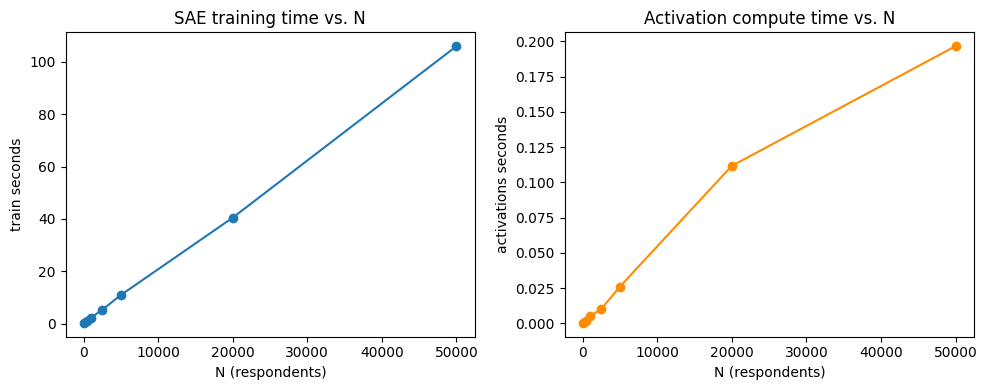

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(df_N["n_responses"], df_N["train_seconds"], marker="o")
axes[0].set(xlabel="N (respondents)", ylabel="train seconds", title="SAE training time vs. N")
axes[1].plot(df_N["n_responses"], df_N["activations_seconds"], marker="o", color="darkorange")
axes[1].set(xlabel="N (respondents)", ylabel="activations seconds", title="Activation compute time vs. N")
fig.tight_layout()
plt.show()

## Sweep 3 (optional): vary `D` (embedding dimensionality)
Fixed `N=1004`, `M=32`. Useful if a reader plans to use a smaller/larger
embedding model than `text-embedding-3-large` (3072-dim). `D` values above
3072 tile the real embeddings rather than reflecting a real embedding model.

In [8]:
D_VALUES = [256, 768, 1536, 3072]  # edit to test other sizes

results_D = []
for d in D_VALUES:
    emb_d = resize_dim(BASE_EMBEDDINGS, d)
    print(f"Benchmarking D={d} ...")
    r = benchmark_sae(emb_d, M=32)
    results_D.append(r)
    print(f"  train={r['train_seconds']:.1f}s  activations={r['activations_seconds']:.2f}s")

df_D = pd.DataFrame(results_D)
df_D

Benchmarking D=256 ...


  train=0.3s  activations=0.00s
Benchmarking D=768 ...


  train=0.5s  activations=0.00s
Benchmarking D=1536 ...


  train=0.9s  activations=0.00s
Benchmarking D=3072 ...


  train=1.8s  activations=0.00s


,n_responses,embedding_dim,M,K,n_epochs,train_seconds,activations_seconds,device
0,1004,256,32,4,100,0.343899,0.000698,mps
1,1004,768,32,4,100,0.516357,0.000932,mps
2,1004,1536,32,4,100,0.854567,0.001493,mps
3,1004,3072,32,4,100,1.831881,0.003229,mps


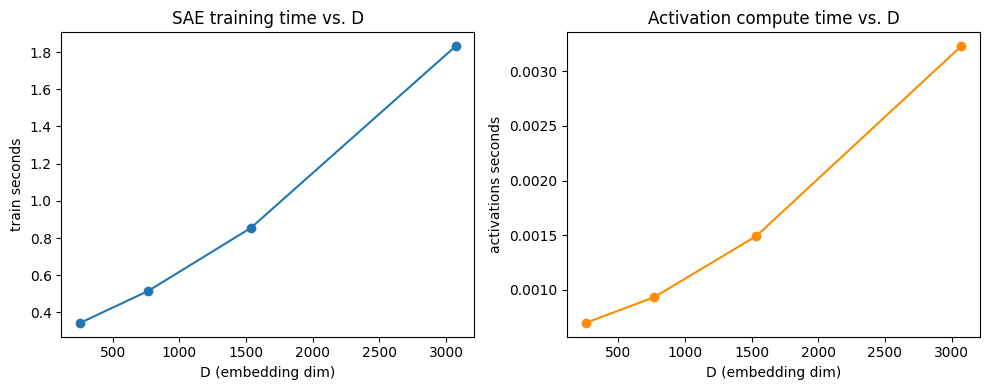

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(df_D["embedding_dim"], df_D["train_seconds"], marker="o")
axes[0].set(xlabel="D (embedding dim)", ylabel="train seconds", title="SAE training time vs. D")
axes[1].plot(df_D["embedding_dim"], df_D["activations_seconds"], marker="o", color="darkorange")
axes[1].set(xlabel="D (embedding dim)", ylabel="activations seconds", title="Activation compute time vs. D")
fig.tight_layout()
plt.show()

## Save combined results

In [10]:
combined = pd.concat(
    [df_M.assign(sweep="M"), df_N.assign(sweep="N"), df_D.assign(sweep="D")],
    ignore_index=True,
)
out_path = DATA_DIR / "sae_timing_benchmark.csv"
combined.to_csv(out_path, index=False)
print(f"Saved: {out_path.relative_to(ROOT)}")
combined

Saved: data/sae_timing_benchmark.csv


,n_responses,embedding_dim,M,K,n_epochs,train_seconds,activations_seconds,device,sweep
0,1004,3072,16,4,100,1.754708,0.004171,mps,M
1,1004,3072,32,4,100,1.917014,0.002956,mps,M
2,1004,3072,48,4,100,1.893326,0.002815,mps,M
3,1004,3072,64,4,100,1.974038,0.002950,mps,M
4,1004,3072,80,4,100,2.061295,0.003128,mps,M
5,1004,3072,128,4,100,2.219674,0.003795,mps,M
6,100,3072,32,4,100,0.355489,0.000295,mps,N
7,500,3072,32,4,100,1.069511,0.001787,mps,N
8,1004,3072,32,4,100,1.701156,0.004415,mps,N
9,2500,3072,32,4,100,4.764141,0.011047,mps,N
